## Notebook to run evaluation scripts for Different attacks

This notebook allows to run our encoder and DTD attack on images put in plonk/.media.
You can add any image you would like, and follow the instructions "#".

Prior to running this code, please install a conda environment with python 3.10 and install all dependencies in requirements.txt

In [5]:
%cd ../
from attacks import *
from plonk.pipe import PlonkPipeline
from PIL import Image
import torch
import tqdm as tqdm
import matplotlib.pyplot as plt
import pandas as pd

from pipe_trajectory import PlonkPipelineTrajectory
from adversarial_utils import *
from plots_adversarial_attacks import plot_gps_samples_on_map, plot_gps_trajectories_on_map

device = torch.device("cuda")



/Data/mathias.ollu/plonk


In [6]:
#choose a model (YFCC with Dinov2, or OSV-5M with ViT-Streeclip)

pipeline = PlonkPipelineTrajectory("nicolas-dufour/PLONK_YFCC_diffusion").to(device)
# pipeline = PlonkPipelineTrajectory("nicolas-dufour/PLONK_OSV_5M_diffusion").to(device)

Using cache found in /users/eleves-b/2023/mathias.ollu/.cache/torch/hub/facebookresearch_dinov2_main
/users/eleves-b/2023/mathias.ollu/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/users/eleves-b/2023/mathias.ollu/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/users/eleves-b/2023/mathias.ollu/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [3]:
budget=10/255

In [7]:
train_args = {"n_steps":50,
		"train_batch_size":256,
		"lr":1e-3,
		"eps_max": budget,
		"anchor_samples":512,
		"clean_num_steps":100,
		"target_pure_noise": False,
		"dot_product_loss":"absolute",
		"reconstruction_loss_weight": 0.0,
		"num_restarts" : 1,
		"restart_selection_metric": "final_step_displacement",
		"restart_eval_cfg": 10.0,
		"device": device}

#choose attack tye
attack_name= "diffusion"
# attack_name= "encoder"


In [5]:
#Choose source/target image (target image can be None, it is not used by the diffusion attack).
source_image_path = "../.media/moscow.png"
source_image = Image.open(source_image_path)


target_image_path = "../.media/moscow.png"
target_image = Image.open(target_image_path)
source_image = Image.open(source_image_path).convert("RGB")
target_image = Image.open(target_image_path).convert("RGB")

In [ ]:
#run attack (approximately 18 seconds for 50 steps on a A500)
results_diffusion = run_attack(attack_name, source_image,pipeline,target_image=target_image, **train_args)
delta=results_diffusion["delta"]

/Data/mathias.ollu/plonk/plonk/models/samplers/ddim.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):
PGD attack training (restart 1/1):  10%|█         | 5/50 [00:01<00:12,  3.75it/s]

PGD attack training (restart 1/1): 100%|██████████| 50/50 [00:13<00:00,  3.80it/s, loss=2.094387]


[restart 1/1] final_loss=1.866933, min_loss=1.744925, mean_step_disp=nan, final_step_disp=4892.606445, selection_score=4892.606445


In [ ]:
#Evaluate trajectories of clean and perturbed image, with a common start noise (6 seconds)
cfg=10
batch_size=1024
#We set a common start noise so as to compare trajectories of perturbed and non perturbed images
x_N = x_N = torch.randn(batch_size, *[3], device="cuda")
pertubed_source = add_perturbation_to_image(source_image, delta, pipeline)

gps_coords_perturbed, traj_perturbed = pipeline(pertubed_source, batch_size=batch_size, cfg=cfg,x_N=x_N, return_trajectories=True)
gps_coords_source, traj_source = pipeline(source_image, batch_size=batch_size,cfg=cfg,x_N=x_N, return_trajectories=True)

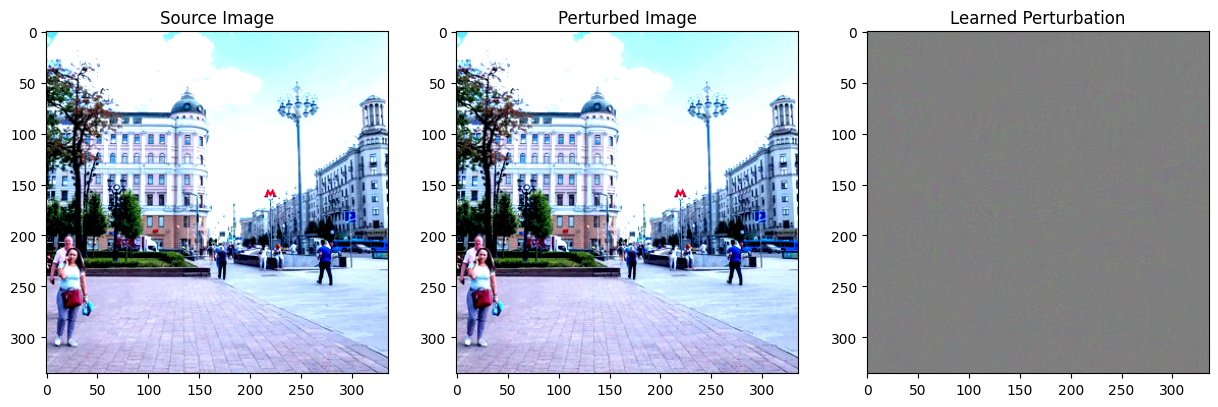

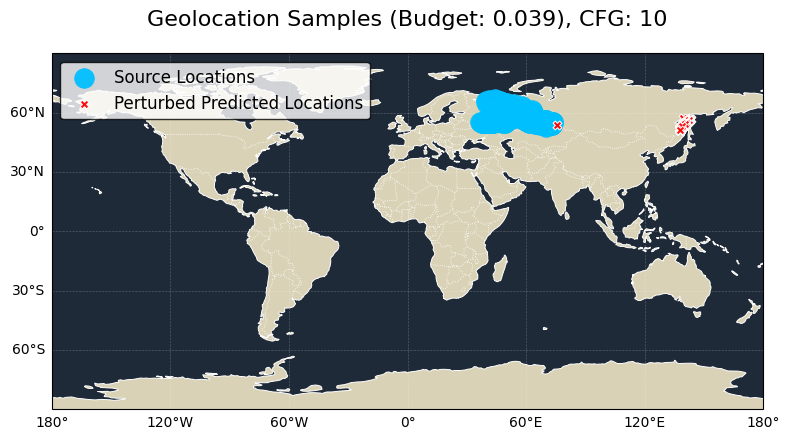

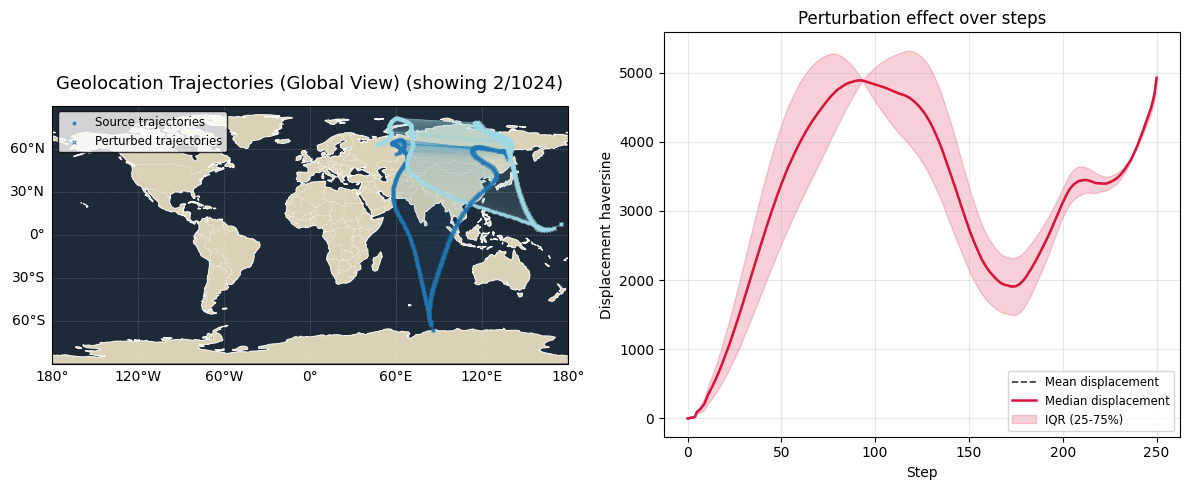

In [ ]:
#plot all 3 images:
source_tensor = conditional_preprocessing(source_image, pipeline, device=device)
source_image_reformatted = tensor_to_pil(source_tensor.squeeze(0))

#convert pertubed image to PIL format:
delta_1_pil= tensor_to_pil(delta)

fig, axs = plt.subplots(1, 3, figsize=(15, 10))
axs[0].imshow(source_image_reformatted)
axs[0].set_title("Source Image")
axs[1].imshow(pertubed_source)
axs[1].set_title("Perturbed Image")
axs[2].imshow(delta_1_pil)
axs[2].set_title("Learned Perturbation")

plt.show()    

#plots of trajectories and gps samples on map
plot_gps_samples_on_map(gps_coords_source, None, gps_coords_perturbed, perturb_budget=budget, cfg=cfg, point_size=40)
plot_gps_trajectories_on_map(traj_source, traj_perturbed, show_map=True, show_paths=True,show_displacement=True, max_trajectories=4)